#### **Exercise 1:**

The `titanic` dataset is widely used in ML courses.  The 'stakeholder problem' is to predict whether or not a person was likely to survive given the available data.  We'll use it here for a few problems to get used to preprocessing data.

First, let's do some EDA.  Load the data in and use a scatter plot matrix to visualize just the numeric columns.  Look critically at your results.

In [1]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

In [2]:
# https://ist707.s3.us-east-2.amazonaws.com/data/titanic.csv
# Load the titanic dataset
url = "https://ist707.s3.us-east-2.amazonaws.com/data/titanic.csv"
titanic_df = pd.read_csv(url)

In [3]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    object 
 9   embarked  1307 non-null   object 
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


In [4]:
titanic_df.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0


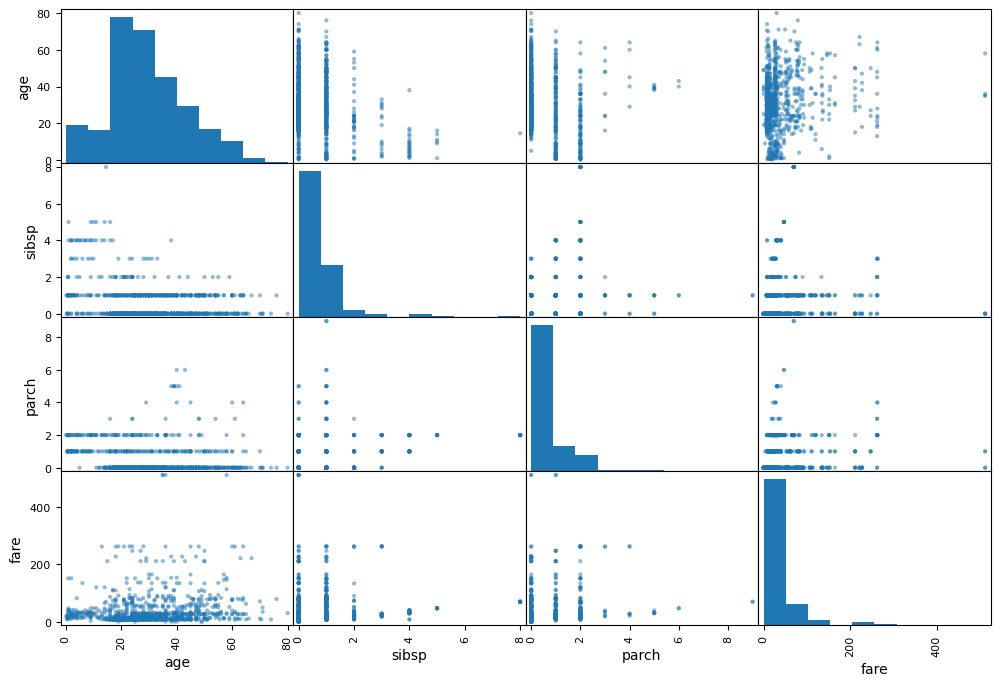

In [5]:
attributes = ['age', 'sibsp', 'parch', 'fare']
scatter_matrix(titanic_df[attributes], figsize=(12, 8))
plt.show()

**Questions:** What have you learned? What would you like to know that this analysis doesn't tell you?

*your answers here*

#### **Exercise 2:**

It's zero cost to build a scatter matrix, but sometimes it only helps to highlight what you *don't* know. In addition to identifying correlations (or lack thereof) we'd also like to get a sense of the predictive power of different features. Plot the relationship between `survival` rate and `age`, `pclass`, and `gender`. Choose appropriate plot types for each variable.

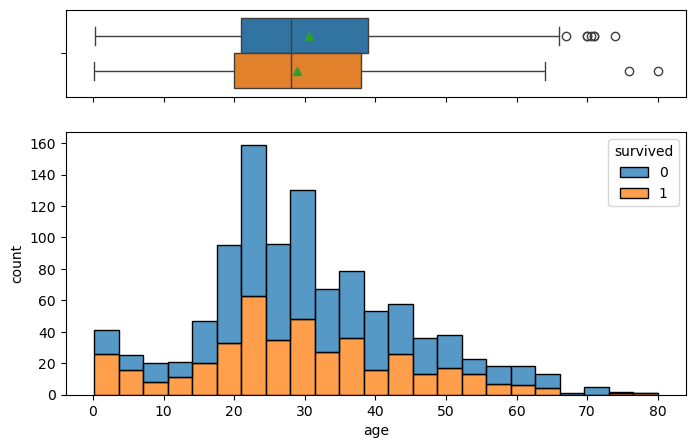

In [6]:
# Histogram boxplot combination plot of survival vs age
fig, (ax_box, ax_hist) = plt.subplots(
    nrows = 2,
    sharex = True,
    figsize = (8, 5),
    gridspec_kw = {'height_ratios': (0.25, 0.75)})

sns.boxplot(titanic_df, x = 'age', hue = 'survived', ax = ax_box, showmeans = True)
ax_box.set(xlabel = '')
ax_box.get_legend().remove()

sns.histplot(titanic_df, x = 'age', hue = 'survived', ax = ax_hist, multiple = 'stack', kde = False)
ax_hist.set(xlabel = 'age', ylabel = 'count')
plt.show()


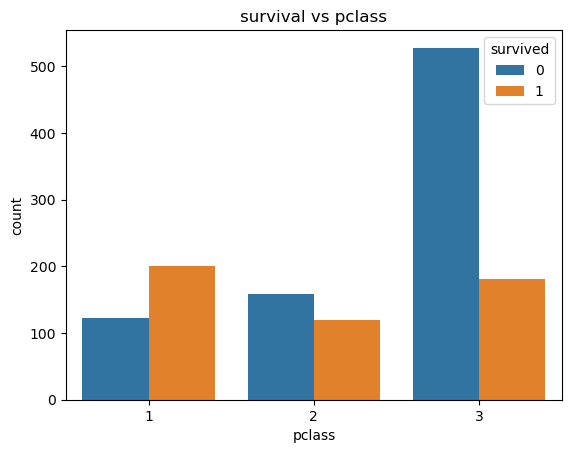

In [7]:
# Survival vs pclass countplot
sns.countplot(titanic_df, x = 'pclass', hue = 'survived')
plt.title('survival vs pclass')
plt.show()

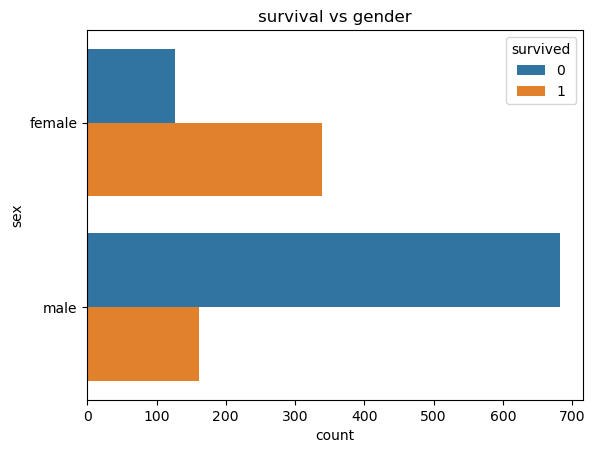

In [8]:
# Survival vs gender countplot
sns.countplot(titanic_df, y = 'sex', hue = 'survived')
plt.title('survival vs gender')
plt.show()

**Question:** What are your general observations? Do any of these variables appear to be useful for predicting `survival`?

Age indicates that younger passengers had a better survival rate, females are far more likley to survive, and first class had the highest survival rate.

#### **Exercise 3:**

Examine your data for NAs.  For the features that you think are likely to matter given your initial analysis, use an imputer to fill in the missing values. For features that you think are of minimal importance and/or have too many NAs to make imputation feasible, drop those features.

In [9]:
# Determine the number of missing values in each attribute
titanic_df.isna().sum().sort_values(ascending = False)

cabin       1014
age          263
embarked       2
fare           1
pclass         0
name           0
sex            0
sibsp          0
parch          0
ticket         0
survived       0
dtype: int64

In [10]:
# Drop unecessary columns
titanic_df.drop(columns = ['cabin', 'ticket', 'name'], inplace = True)

In [11]:
# Group by pclass and sex, then impute age NA's with median
titanic_df['age'] = titanic_df.groupby(['pclass', 'sex'])['age'].transform(
    lambda x: x.fillna(x.median())
)

In [12]:
# Utlize SKLearn's imputation methods for remaining NA's
fare_imputer = SimpleImputer(strategy = 'median')
titanic_df[['fare']] = fare_imputer.fit_transform(titanic_df[['fare']])

embarked_imputer = SimpleImputer(strategy = 'most_frequent')
titanic_df[['embarked']] = embarked_imputer.fit_transform(titanic_df[['embarked']])

In [13]:
# Determine the number of missing values in each attribute
titanic_df.isna().sum().sort_values(ascending = False)

pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64

#### **Exercise 4:**

Recall that `sklearn` does not handle strings. Use an **encoder** to transform any string columns into numbers. If there are any categorical columns where label encoding won't work, use a **one-hot encoder**.

In [14]:
# Define categorical attributes
categorical = ['sex', 'embarked', 'pclass']
categorical_df = titanic_df[categorical]

In [15]:
# Utlize SKLearn OHE methods to encode variables
ohe_encoder = OneHotEncoder(drop = 'first', sparse_output = False)
titanic_ohe = ohe_encoder.fit_transform(categorical_df)

encoded_df = pd.DataFrame(
    titanic_ohe,
    columns = ohe_encoder.get_feature_names_out(categorical),
    index = titanic_df.index
)

titanic_df_ohe = titanic_df.drop(columns = categorical)
titanic_df_ohe = titanic_df_ohe.join(encoded_df)

In [16]:
titanic_df_ohe.head()

,age,sibsp,parch,fare,survived,sex_male,embarked_Q,embarked_S,pclass_2,pclass_3
0,29.0000,0,0,211.3375,1,0.0,0.0,1.0,0.0,0.0
1,0.9167,1,2,151.5500,1,1.0,0.0,1.0,0.0,0.0
2,2.0000,1,2,151.5500,0,0.0,0.0,1.0,0.0,0.0
3,30.0000,1,2,151.5500,0,1.0,0.0,1.0,0.0,0.0
4,25.0000,1,2,151.5500,0,0.0,0.0,1.0,0.0,0.0


#### **Exercise 5:**

Using 5-fold cross-validation, compare the performance of a `LogisticRegression` classifier with that of a `DecisionTree` classifier in **predicting survival**.

In [17]:
# Drop target variable
X = titanic_df_ohe.drop(columns = 'survived')
y = titanic_df_ohe['survived']

In [18]:
# Two numeric features for visualization
X_vis = X[['age', 'fare']]
scaler = StandardScaler()
X_vis_scaled = scaler.fit_transform(X_vis)

In [19]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

log_clf = LogisticRegression(max_iter=1000)
log_scores = cross_val_score(log_clf, X, y, cv=kf, scoring='accuracy')

In [20]:
# Run logistic decision tree classifer model 5 fold cv
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_scores = cross_val_score(tree_clf, X, y, cv=kf, scoring='accuracy')

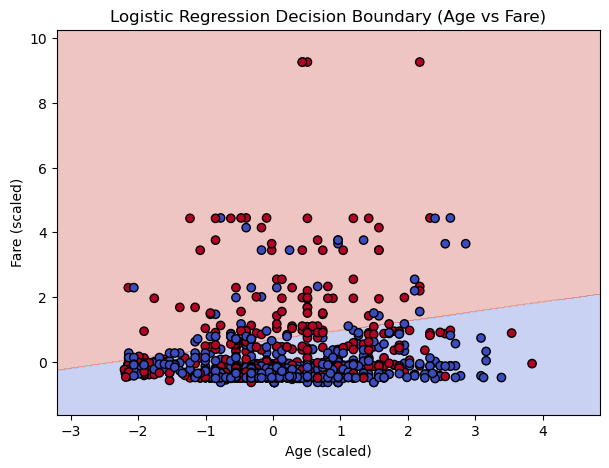

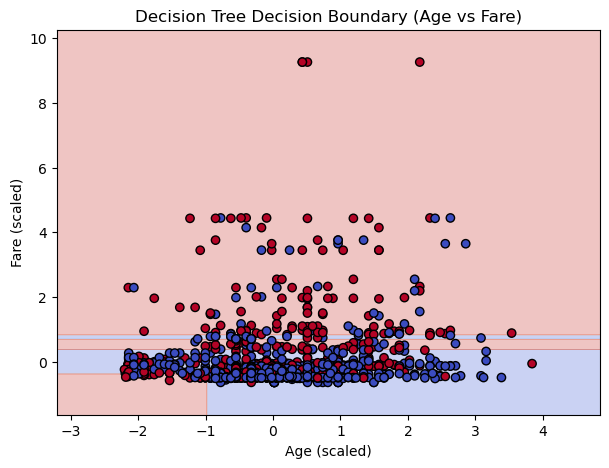

In [21]:
# visualize the decision boundary
x_min, x_max = X_vis_scaled[:, 0].min() - 1, X_vis_scaled[:, 0].max() + 1
y_min, y_max = X_vis_scaled[:, 1].min() - 1, X_vis_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))

for model, name in [(log_clf, "Logistic Regression"), (tree_clf, "Decision Tree")]:
    model.fit(X_vis_scaled, y)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X_vis_scaled[:, 0], X_vis_scaled[:, 1], c=y, cmap='coolwarm', edgecolor='k')
    plt.title(f"{name} Decision Boundary (Age vs Fare)")
    plt.xlabel("Age (scaled)")
    plt.ylabel("Fare (scaled)")
    plt.show()

| Model | Mean Accuracy | Std Dev | Boundary Shape |
| --- | --- | --- | --- |
| LogisticRegression | Linear (smooth line) | Lower variance |
| DecisionTree | Non‑linear (step‑like) | Higher variance |

In [22]:
# Compare mean cv accuracy

print("LogisticRegression mean accuracy:", log_scores.mean(), "±", log_scores.std())
print("DecisionTree mean accuracy:", tree_scores.mean(), "±", tree_scores.std())

LogisticRegression mean accuracy: 0.7898862273697758 ± 0.024080942485532025
DecisionTree mean accuracy: 0.7959901728525051 ± 0.03227949810596462


When you compare Logistic Regression and a Decision Tree on the Titanic survival task, you’re really comparing two very different hypotheses about how the world works. The contrast is sharp, and it shows up in accuracy, variance, interpretability, and the geometry of the decision boundary.
Logistic Regression
Assumes the log‑odds of survival are a linear combination of the features.

Every feature pushes the probability up or down in a smooth, monotonic way.

Works best when relationships are globally linear or close to it.

Decision Tree
Assumes the feature space can be carved into rectangular regions using threshold splits.

Captures non‑linear, interaction‑heavy, and piecewise relationships.

Works best when the true boundary is irregular or hierarchical (“if age < 12 AND fare > 30…”).

2. Cross‑validation performance (typical pattern on Titanic)
You’ll see something like:

| Model | Mean Accuracy | Variance | Notes |
| --- | --- | --- | --- |
| **Logistic Regression** | ~0.77–0.80 | Low | Stable, robust, underfits slightly |
| **Decision Tree** | ~0.78–0.82 | Higher | Can outperform LR but is more volatile |

Trees often edge out LR on Titanic because survival is not purely linear — there are sharp thresholds (children, high‑fare passengers, women, etc.).